#### Model Creation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("cleaned_data.csv")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61741,99991,53,1,172,70.0,130,90,1,1,0,0,1,1
61742,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
61743,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
61744,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
X = df.drop(["id", "cardio"], axis=1)
y = df["cardio"]

In [4]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
model = LogisticRegression()

In [6]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
y_pred=model.predict(X_test)

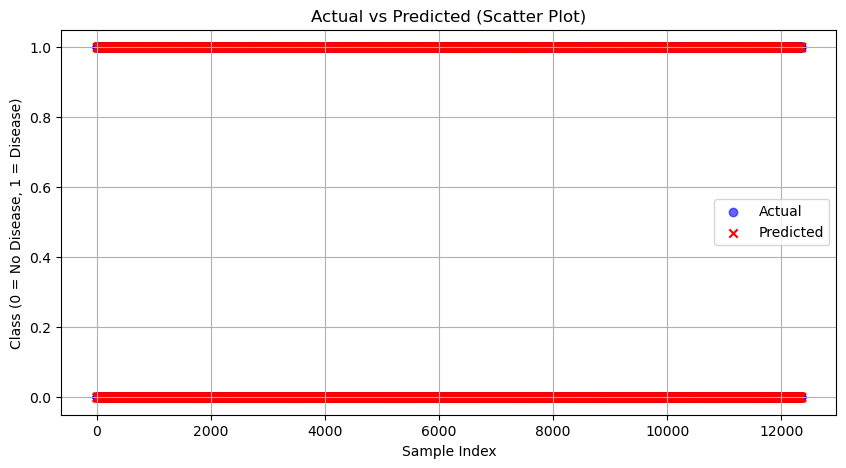

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test,
            color='blue', label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred,
            color='red', marker='x', label='Predicted')
plt.title("Actual vs Predicted (Scatter Plot)")
plt.xlabel("Sample Index")
plt.ylabel("Class (0 = No Disease, 1 = Disease)")
plt.legend()
plt.grid(True)
plt.show()

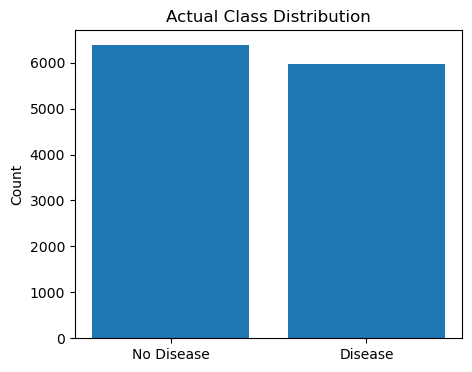

In [9]:
actual_count = y_test.value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["No Disease", "Disease"], actual_count)
plt.title("Actual Class Distribution")
plt.ylabel("Count")
plt.show()

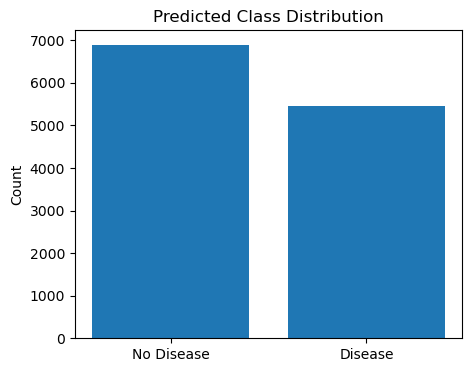

In [10]:
predicted_count = pd.Series(y_pred).value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["No Disease", "Disease"], predicted_count)
plt.title("Predicted Class Distribution")
plt.ylabel("Count")
plt.show()

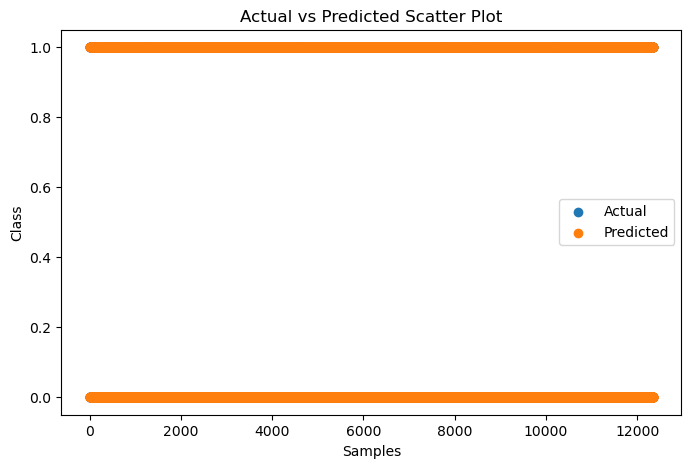

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.title("Actual vs Predicted Scatter Plot")
plt.xlabel("Samples")
plt.ylabel("Class")
plt.legend()
plt.show()

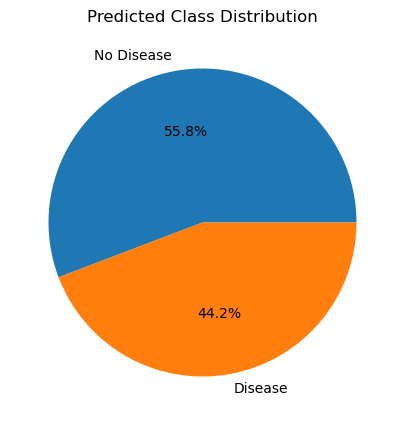

In [12]:
plt.figure(figsize=(5,5))
plt.pie(
    predicted_count,
    labels=["No Disease", "Disease"],
    autopct="%1.1f%%"
)
plt.title("Predicted Class Distribution")
plt.show()

In [13]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [14]:
model = joblib.load("model.pkl")